# Prediction of Mortality in Primary Biliary Cirrhosis Patients Using Machine Learning

## 🎯 Project Purpose

The purpose of this project is to develop a classification model that predicts whether a patient with Primary Biliary Cirrhosis (PBC) will experience death based on clinical, demographic, and laboratory measurements recorded at baseline.

The dataset originates from a clinical study conducted at the Mayo Clinic evaluating patients diagnosed with PBC.

By building a predictive model, this project aims to:

  - Identify high-risk patients early

  - Support clinical decision-making

  - Understand which medical variables most strongly influence mortality

  - Demonstrate the application of machine learning techniques in healthcare data

## 📖 Project Overview
### 1️⃣ Problem Type

This is a binary classification problem:

Target Variable:
Status

  - 0 → Alive (C)

  - 1 → Dead / Transplant (D, CL)

Goal: Predict whether a patient will die based on baseline features.

### 2️⃣ Dataset Description

The dataset contains 424 patients diagnosed with Primary Biliary Cirrhosis. It includes:

  🔹 Demographic Features: Age, Sex

  🔹 Clinical Indicators: Ascites, Hepatomegaly, Edema, Spiders

  🔹 Laboratory Measurements: Bilirubin, Albumin, Cholesterol, Copper, Platelets, Prothrombin, SGOT, Alkaline Phosphatase, Triglycerides

  🔹 Treatment Variable: Drug (D-penicillamine or placebo)

### 3️⃣ Methodology

#### Load Dataset

In [26]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/cirrhosis-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cirrhosis-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/cirrhosis-prediction-dataset


In [27]:
import pandas as pd

# Load the dataset
data = pd.read_csv(f"{path}/cirrhosis.csv")
data.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


#### Data Preprocessing

##### Import libraries

In [28]:
!pip install kmodes

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from kmodes.kprototypes import KPrototypes


##### Inspect Data

In [30]:
df = data.copy()  # Work on a copy
df.drop('ID', axis=1, inplace=True)  # Irrelevant
print(df.shape)  # (418, 19)
print(df.dtypes)  # Check types
print(df.head())  # Sample rows

(418, 19)
N_Days             int64
Status            object
Drug              object
Age                int64
Sex               object
Ascites           object
Hepatomegaly      object
Spiders           object
Edema             object
Bilirubin        float64
Cholesterol      float64
Albumin          float64
Copper           float64
Alk_Phos         float64
SGOT             float64
Tryglicerides    float64
Platelets        float64
Prothrombin      float64
Stage            float64
dtype: object
   N_Days Status             Drug    Age Sex Ascites Hepatomegaly Spiders  \
0     400      D  D-penicillamine  21464   F       Y            Y       Y   
1    4500      C  D-penicillamine  20617   F       N            Y       Y   
2    1012      D  D-penicillamine  25594   M       N            N       N   
3    1925      D  D-penicillamine  19994   F       N            Y       Y   
4    1504     CL          Placebo  13918   F       N            Y       Y   

  Edema  Bilirubin  Cholesterol  Album

In [31]:
df.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


##### Target Class

In [32]:
# Create a new column for the binary target
# We map 'C' to 0 (No failure), and both 'D' and 'CL' to 1 (Liver failure/Death)
df['Target_Failure'] = df['Status'].map({'C': 0, 'D': 1, 'CL': 1})

# Drop the old Status column to avoid duplicate data
df = df.drop(columns=['Status'])

# Check your work
df.head()

,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Target_Failure
0,400,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,1
1,4500,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,0
2,1012,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,1
3,1925,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,1
4,1504,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,1


In [33]:
# Remove the ID (useless noise) and N_Days (Data Leakage)
df = df.drop(columns=['N_Days'], errors='ignore')

In [34]:
df.head()

,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Target_Failure
0,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,1
1,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,0
2,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,1
3,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,1
4,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,1


##### Type conversion

- All object columns are covert to category
- Stage,Status cloumns convert to category

In [35]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

df['Stage'] = df['Stage'] .astype('category')
df['Target_Failure'] = df['Target_Failure'] .astype('category')
print(df.dtypes)

Drug              category
Age                  int64
Sex               category
Ascites           category
Hepatomegaly      category
Spiders           category
Edema             category
Bilirubin          float64
Cholesterol        float64
Albumin            float64
Copper             float64
Alk_Phos           float64
SGOT               float64
Tryglicerides      float64
Platelets          float64
Prothrombin        float64
Stage             category
Target_Failure    category
dtype: object


##### Missing Values Analysis

Tryglicerides    32.535885
Cholesterol      32.057416
Copper           25.837321
Drug             25.358852
Spiders          25.358852
Hepatomegaly     25.358852
Ascites          25.358852
Alk_Phos         25.358852
SGOT             25.358852
Platelets         2.631579
Stage             1.435407
Prothrombin       0.478469
dtype: float64


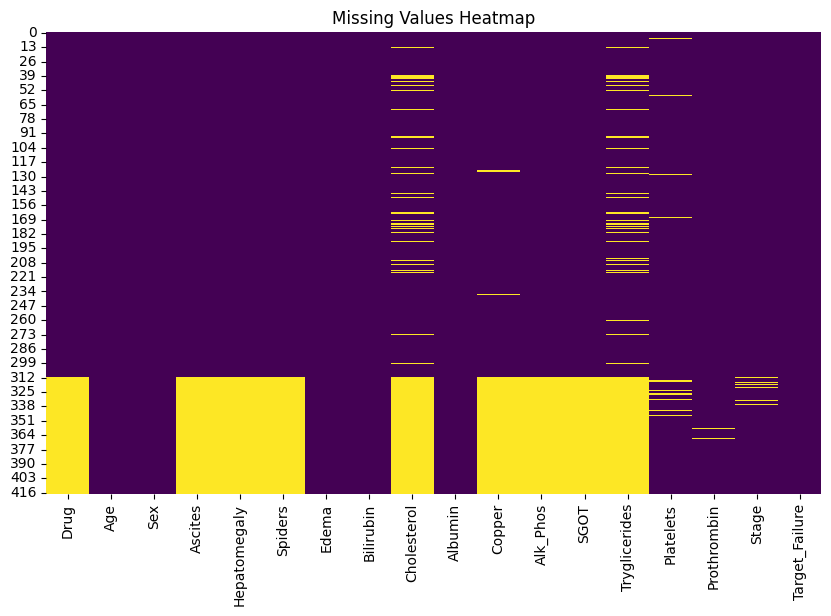

In [36]:
missing_perc = df.isnull().mean() * 100
print(missing_perc[missing_perc > 0].sort_values(ascending=False))  # e.g., Triglycerides: 32.3%

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

##### Drop missing values and impute
- Drop missing values if Drug,Ascites,Hepatomegaly,Spiders,Cholesterol,Copper,Alk_Phos,Tryglicerides missing
- Impute other missing values using KNN Imputer

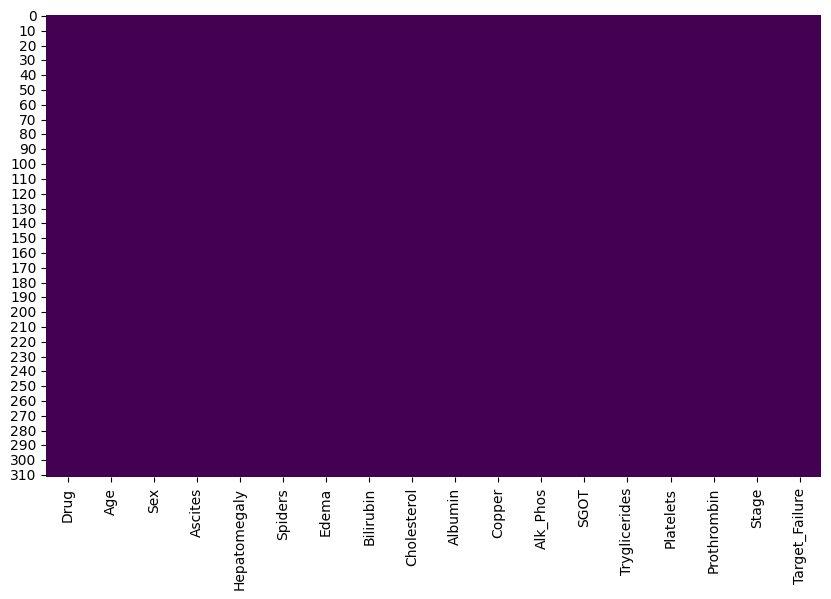

In [37]:
# 1. Clean the categorical starting point
df = df.dropna(subset=['Drug'])

# 2. Define features and initialize tools
num_features = ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 
                'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

scaler = StandardScaler()
imputer = KNNImputer(n_neighbors=5)

# 3. STEP-BY-STEP: Scale -> Impute -> Unscale (to keep original units)
# We scale first so KNN distance is fair
scaled_data = scaler.fit_transform(df[num_features])

# Now we fill the holes based on the scaled 'fair' distances
imputed_data = imputer.fit_transform(scaled_data)

# We convert back to original units so 'Age' isn't a small decimal anymore
df[num_features] = scaler.inverse_transform(imputed_data)

# 4. Verify with your Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [38]:
df.head()

,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Target_Failure
0,D-penicillamine,21464.0,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,1
1,D-penicillamine,20617.0,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,0
2,D-penicillamine,25594.0,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,1
3,D-penicillamine,19994.0,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,1
4,Placebo,13918.0,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,1


#### Clustering

Categorical Columns: Index(['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Stage'], dtype='object')
Categorical Indices: [0, 2, 3, 4, 5, 6, 16]


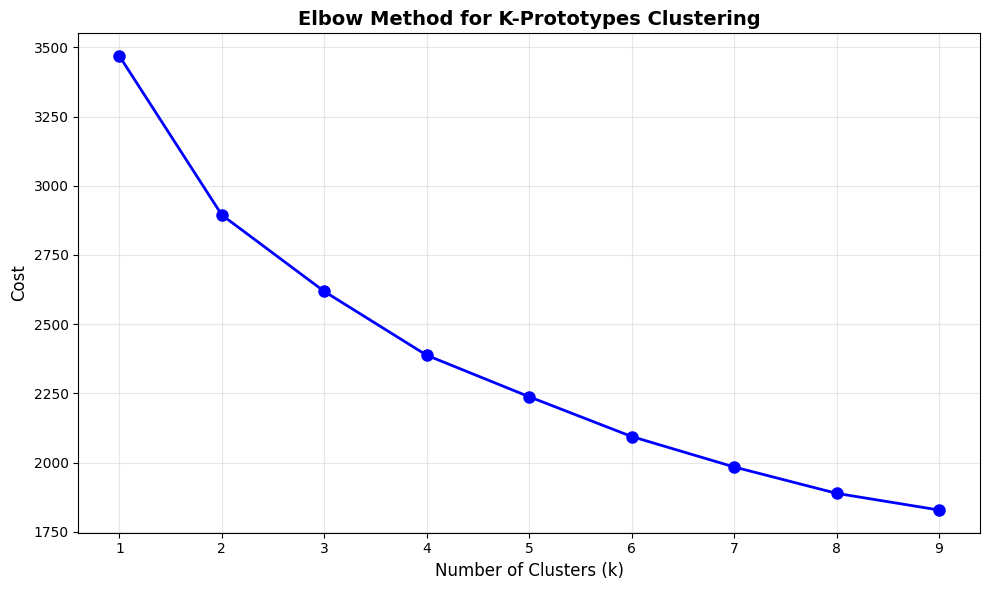

K range tested: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Costs: [np.float64(3468.5000000000027), np.float64(2894.1995485710536), np.float64(2618.0525049929465), np.float64(2387.451944874279), np.float64(2237.6109483863306), np.float64(2093.8783950405905), np.float64(1983.9144886365386), np.float64(1888.6598136340822), np.float64(1828.3435831227396)]


In [39]:
# Prepare data for K-Prototypes clustering
X = df.drop(columns=['Target_Failure'])  # Drop the binary target, we want to cluster on the original features

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

# Scale numerical features
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
X[num_cols] = X[num_cols].astype(float)

# Convert categorical columns to string
for col in cat_cols:
    X[col] = X[col].astype(str)

# Convert to numpy
X_matrix = np.array(X.values, dtype=object)

# Get categorical column indices
cat_indices = [X.columns.get_loc(col) for col in cat_cols]

print("Categorical Columns:", cat_cols)
print("Categorical Indices:", cat_indices)

# Elbow Method for K-Prototypes clustering
costs = []
K_range = range(1, 10)

for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Huang', random_state=42, verbose=0)
    clusters = kproto.fit_predict(X_matrix, categorical=cat_indices)
    costs.append(kproto.cost_)

# Visualize the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(K_range, costs, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Cost", fontsize=12)
plt.title("Elbow Method for K-Prototypes Clustering", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print(f"K range tested: {list(K_range)}")
print(f"Costs: {costs}")

In [40]:
# Fit Final Model
optimal_k = 2

kproto = KPrototypes(n_clusters=optimal_k, init='Huang', random_state=42)
clusters = kproto.fit_predict(X_matrix, categorical=cat_indices)

df["Cluster"] = clusters

In [41]:
df.head()

,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Target_Failure,Cluster
0,D-penicillamine,21464.0,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,1,0
1,D-penicillamine,20617.0,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,0,1
2,D-penicillamine,25594.0,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,1,1
3,D-penicillamine,19994.0,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,1,1
4,Placebo,13918.0,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,1,1


In [42]:
# Clusters and Target Failure	comparison
pd.crosstab(df['Cluster'], df['Target_Failure'])

Target_Failure,0,1
Cluster,,
0,11,67
1,157,77


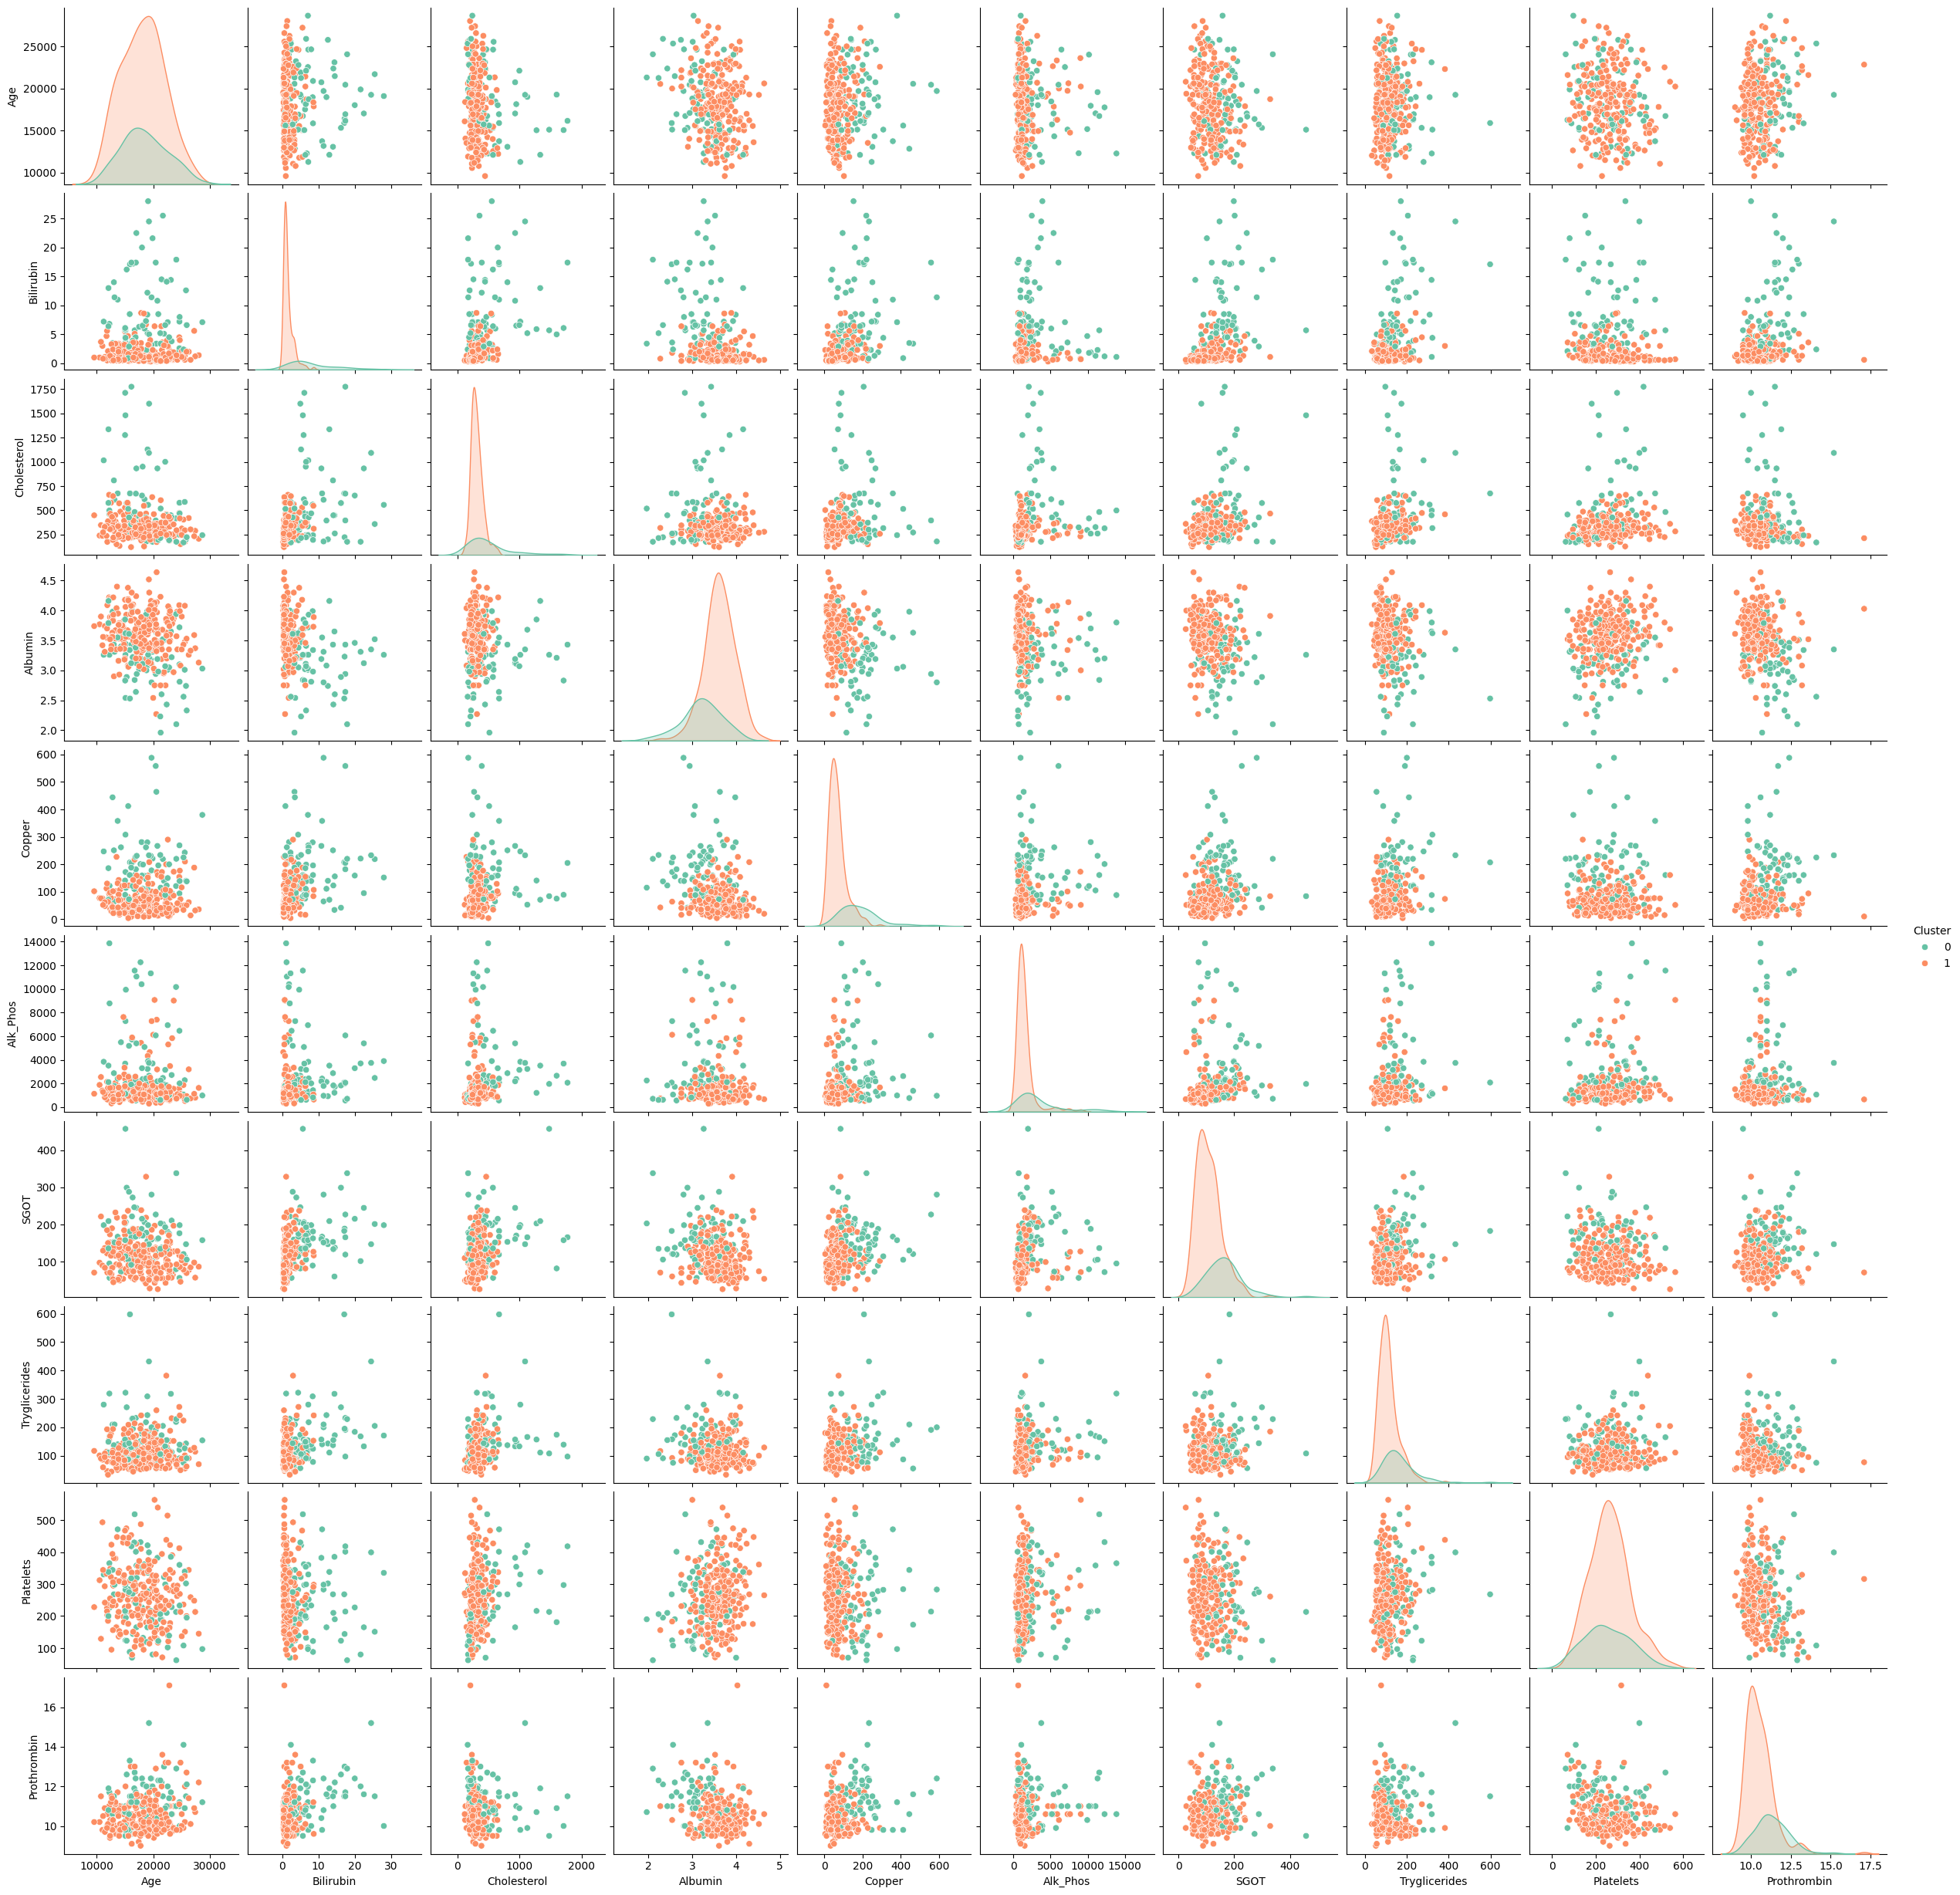

In [43]:
# Keep only numeric columns for pairplot (excluding the target)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()


# Make sure Cluster is included
plot_df = df[numeric_cols + ["Cluster"]]

# Pairplot
sns.pairplot(plot_df, hue="Cluster", palette="Set2", diag_kind="kde")

plt.show()

#### EDA

##### Summary Statistics

In [44]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [col for col in num_cols if col not in ['Target_Failure', 'Cluster']]
cat_cols = df.select_dtypes(include=['category']).columns
print(df[num_cols].describe())

                Age   Bilirubin  Cholesterol     Albumin      Copper  \
count    312.000000  312.000000   312.000000  312.000000  312.000000   
mean   18269.442308    3.256090   367.099359    3.520000   97.472436   
std     3864.805407    4.530315   223.674581    0.419892   85.371815   
min     9598.000000    0.300000   120.000000    1.960000    4.000000   
25%    15427.750000    0.800000   252.000000    3.310000   41.750000   
50%    18187.500000    1.350000   312.900000    3.550000   73.000000   
75%    20715.000000    3.425000   396.000000    3.800000  123.000000   
max    28650.000000   28.000000  1775.000000    4.640000  588.000000   

           Alk_Phos        SGOT  Tryglicerides   Platelets  Prothrombin  
count    312.000000  312.000000     312.000000  312.000000   312.000000  
mean    1982.655769  122.556346     124.881410  261.789744    10.725641  
std     2140.388824   56.699525      63.306152   95.010588     1.004323  
min      289.000000   26.350000      33.000000   62.000

##### Univariant Distributions

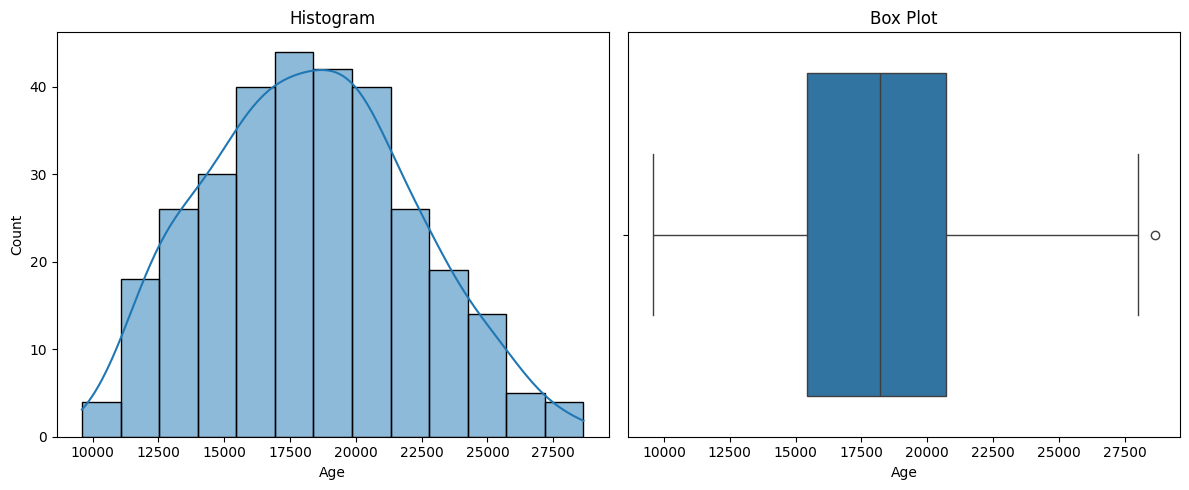

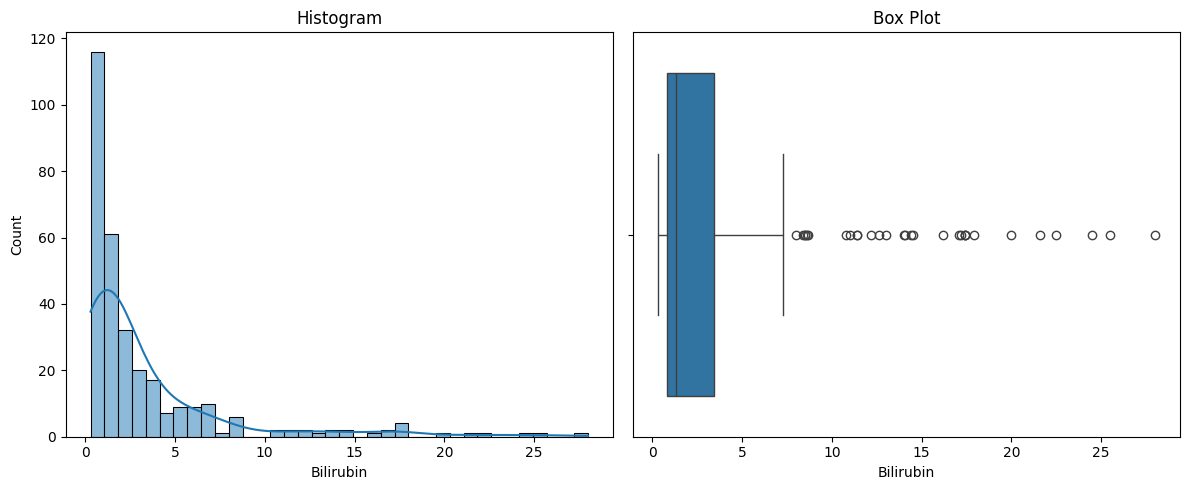

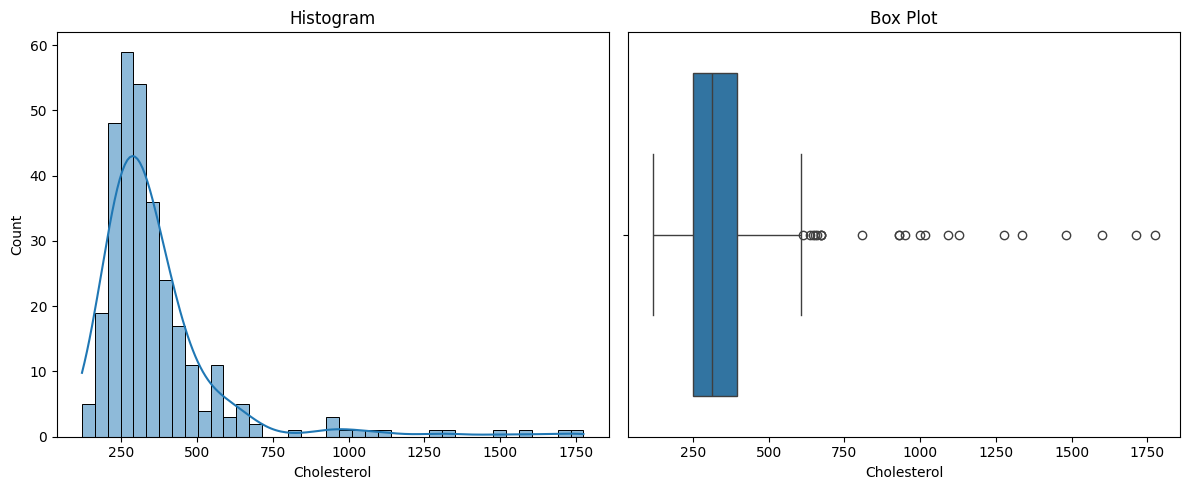

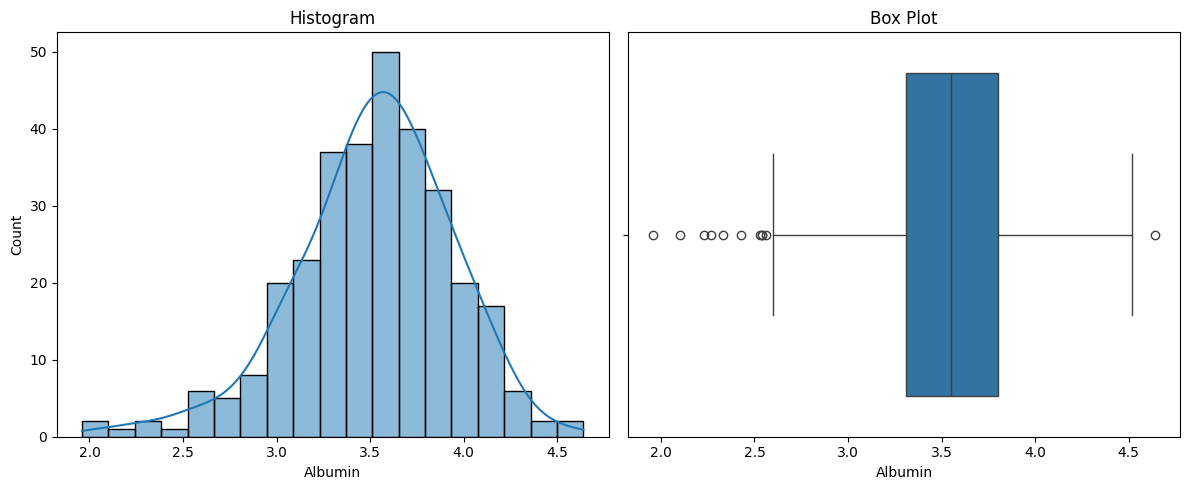

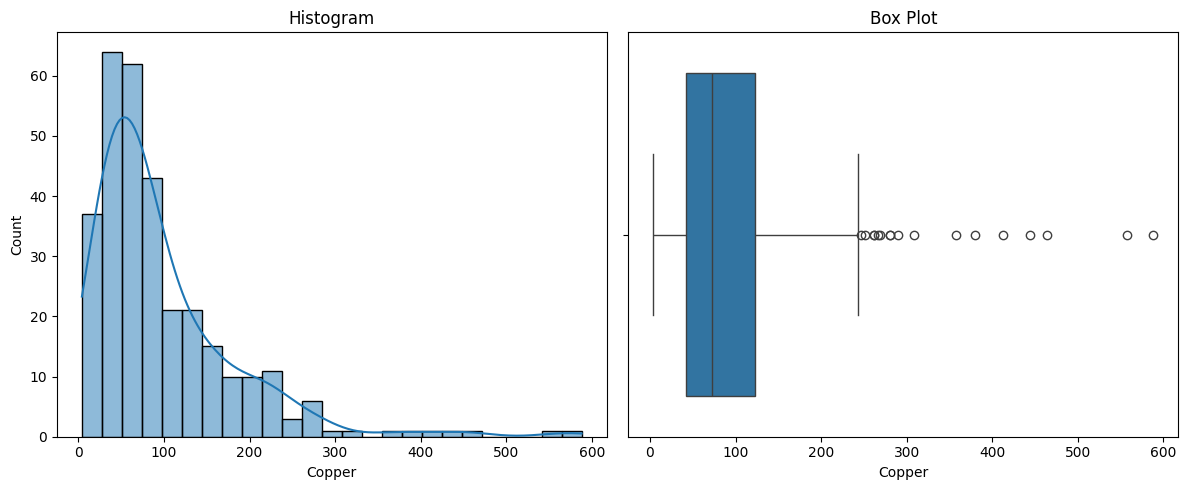

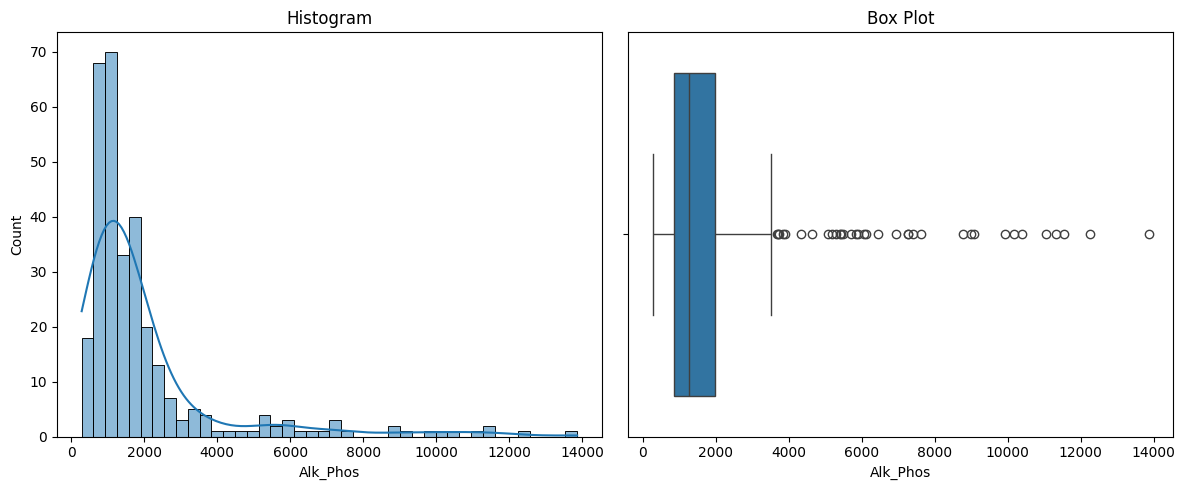

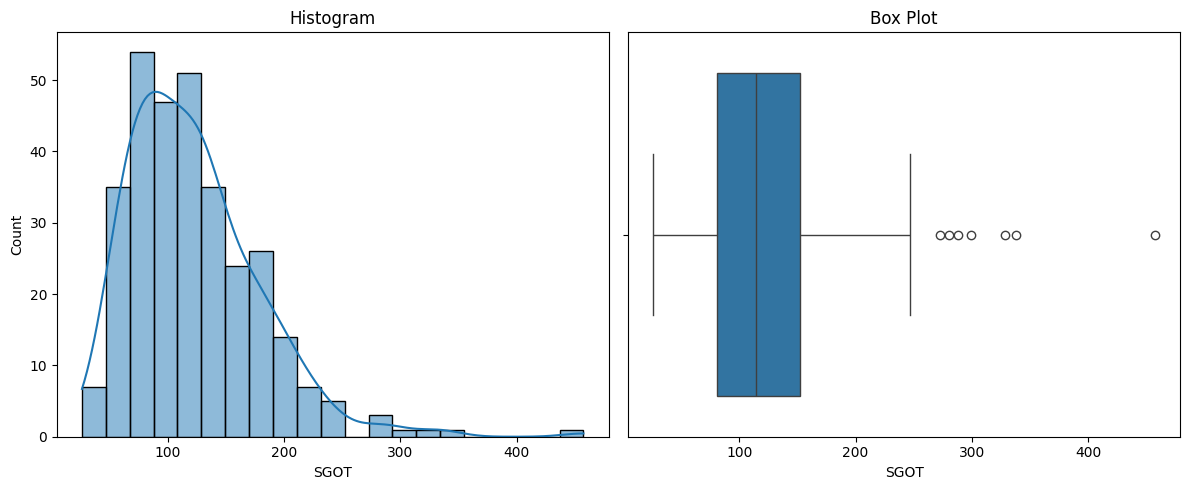

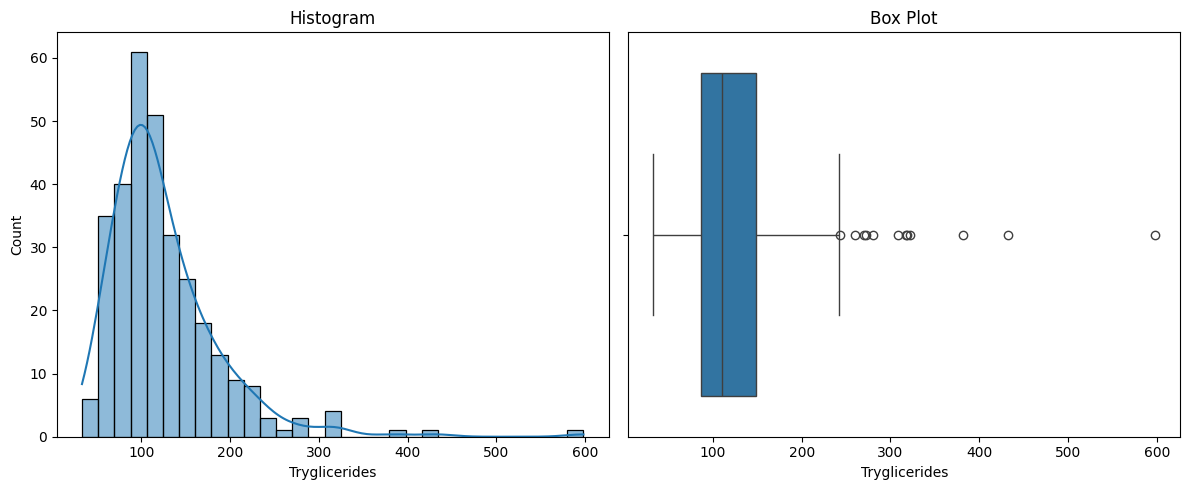

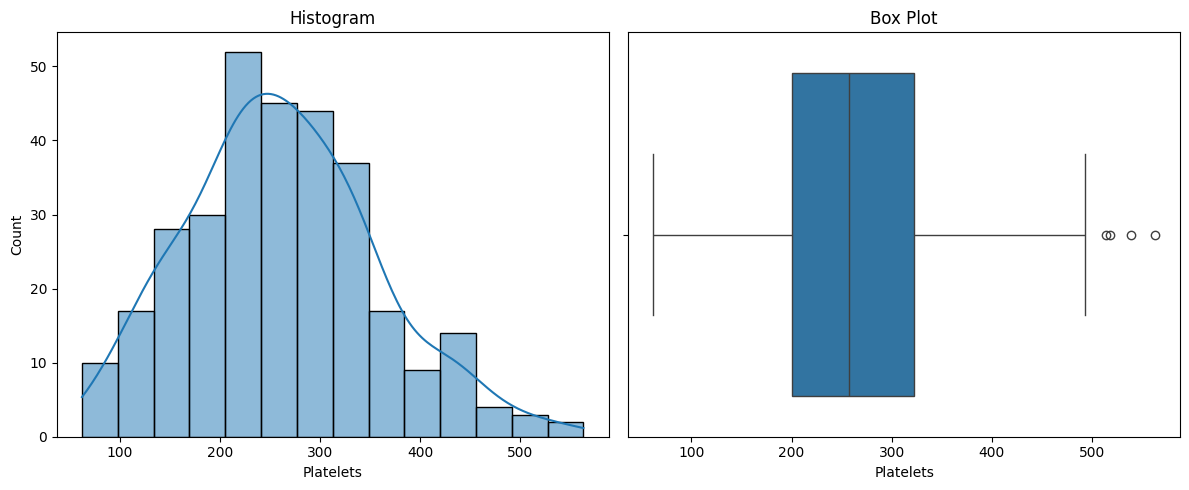

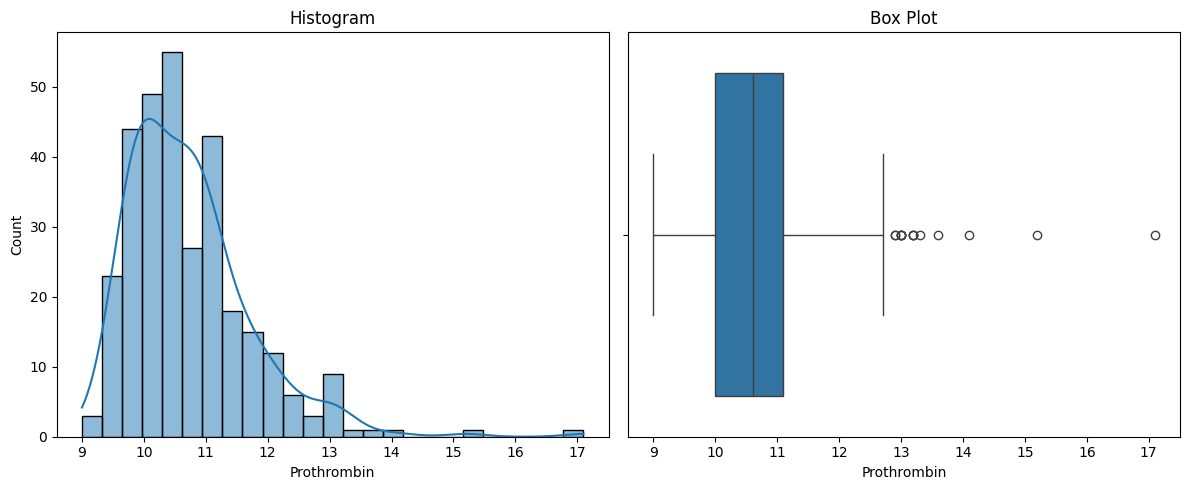

In [45]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title("Histogram")
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title("Box Plot")
    plt.tight_layout()
    plt.show()


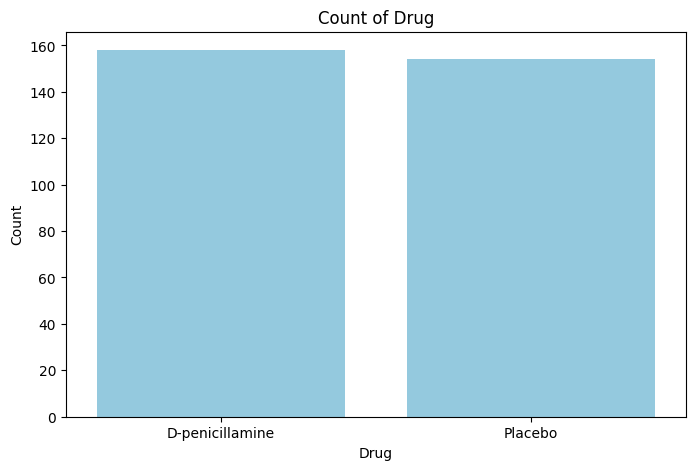

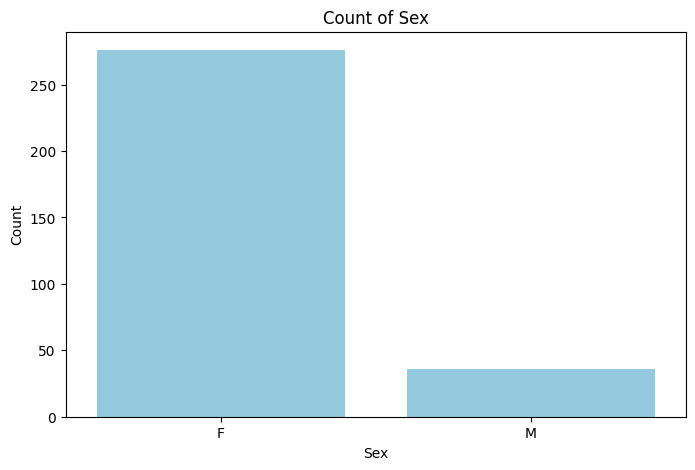

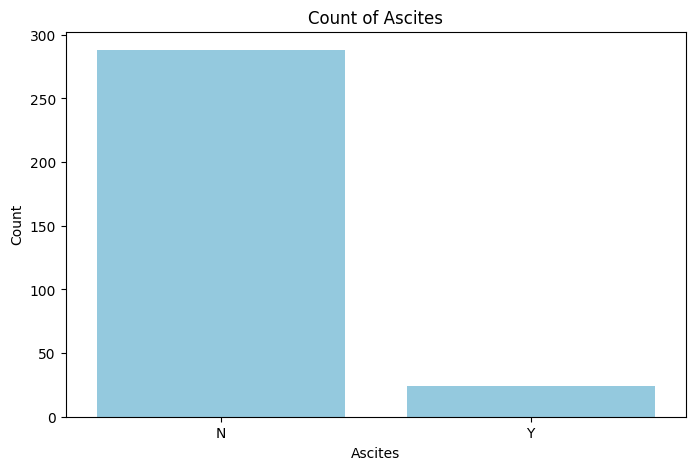

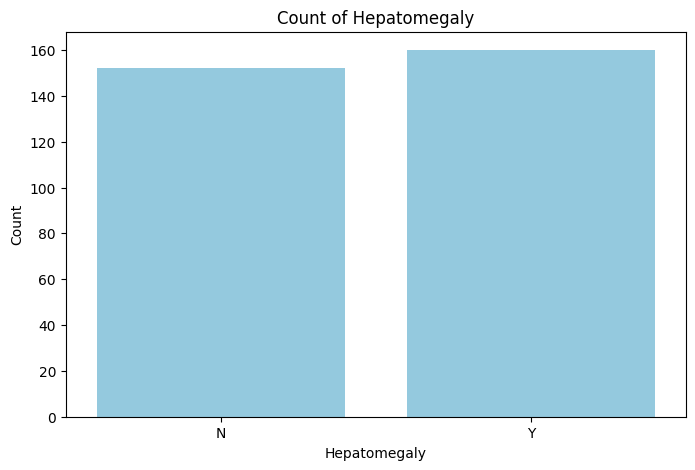

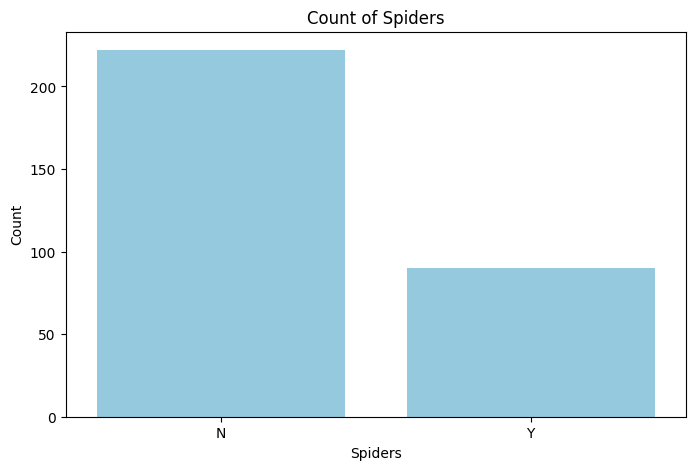

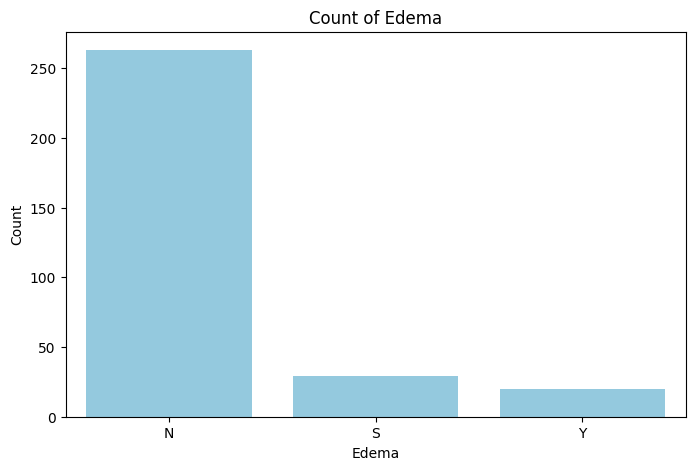

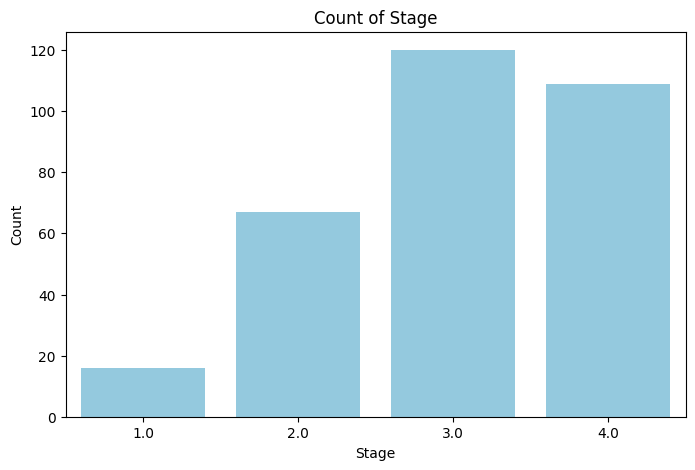

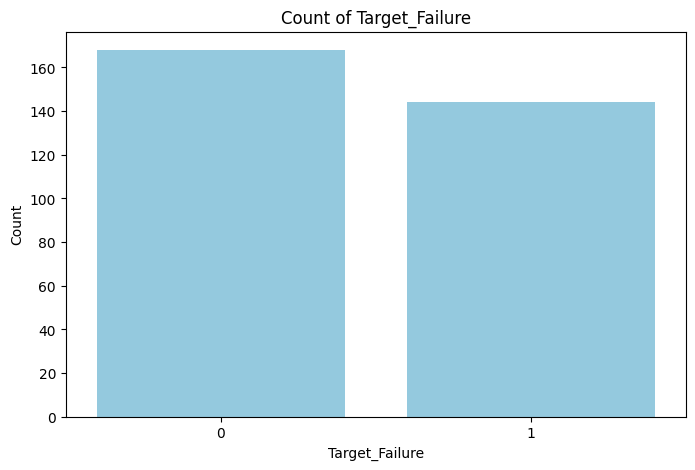

In [46]:
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, data=df, color='skyblue')
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

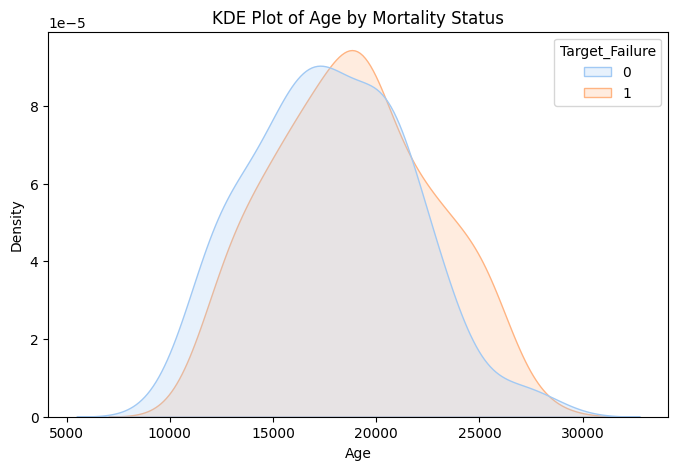

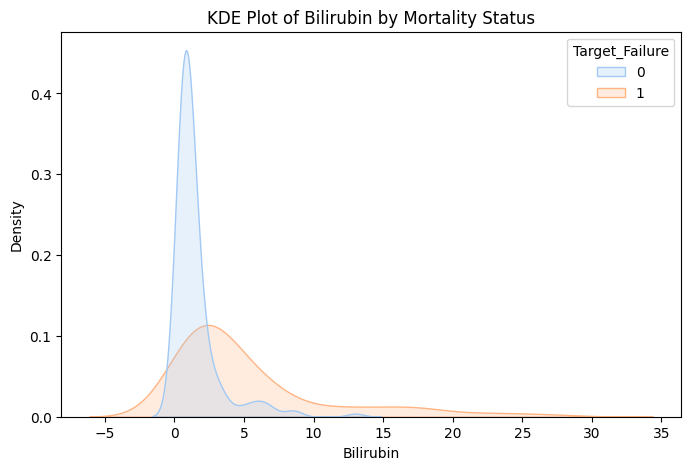

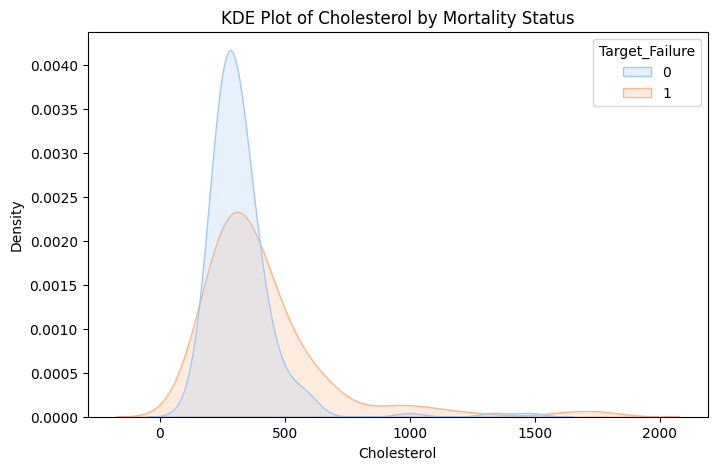

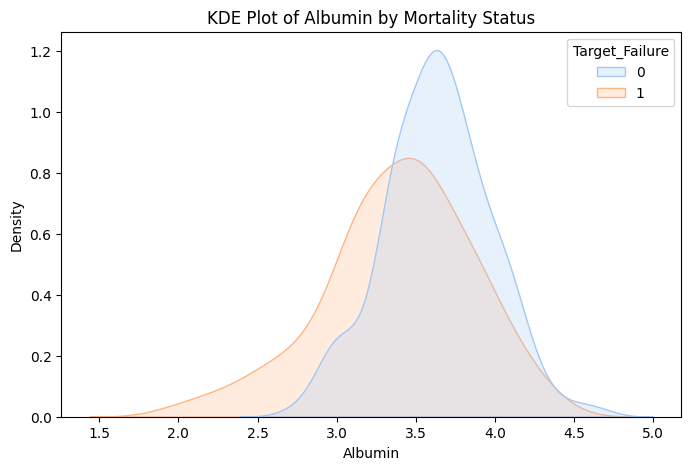

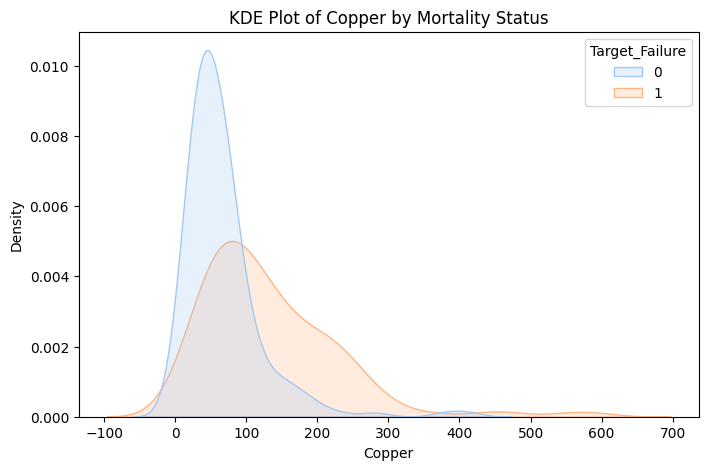

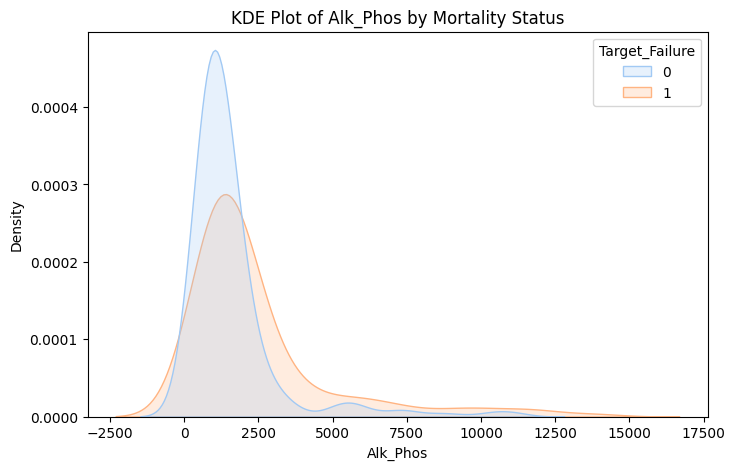

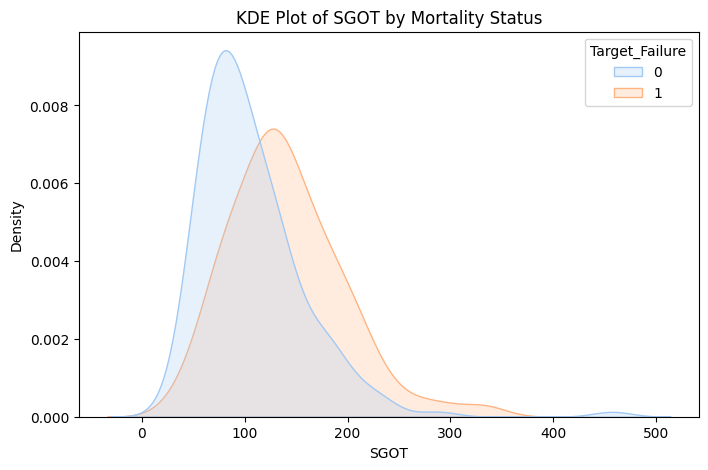

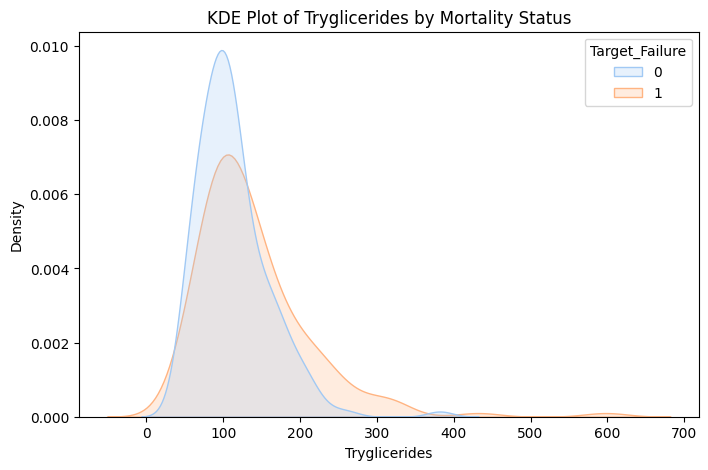

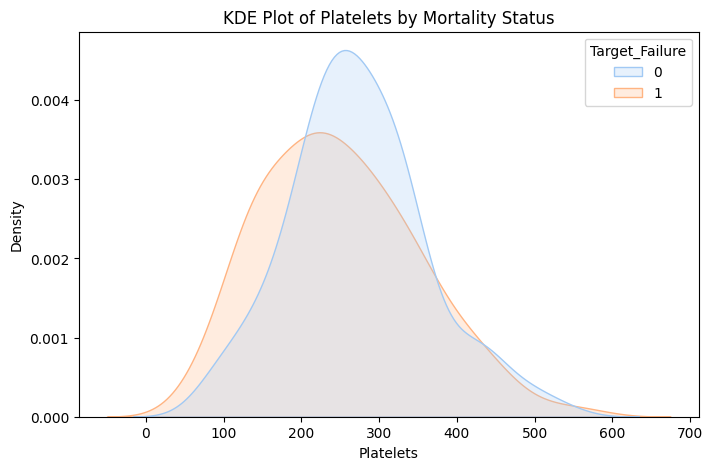

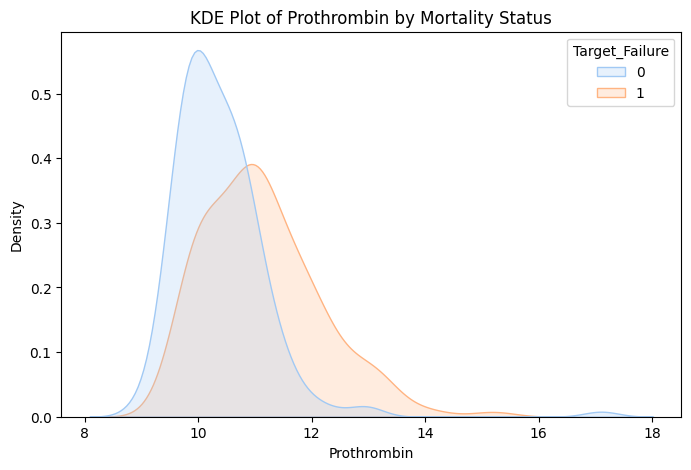

In [47]:
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=df, x=col, hue="Target_Failure", fill=True, common_norm=False, palette='pastel')
    plt.title(f"KDE Plot of {col} by Mortality Status")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()

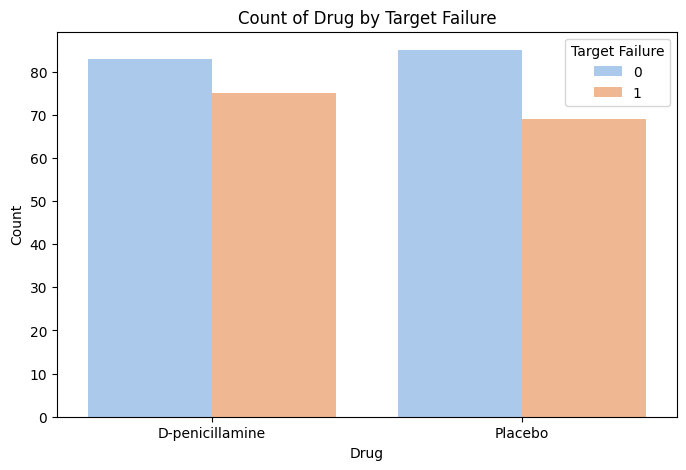

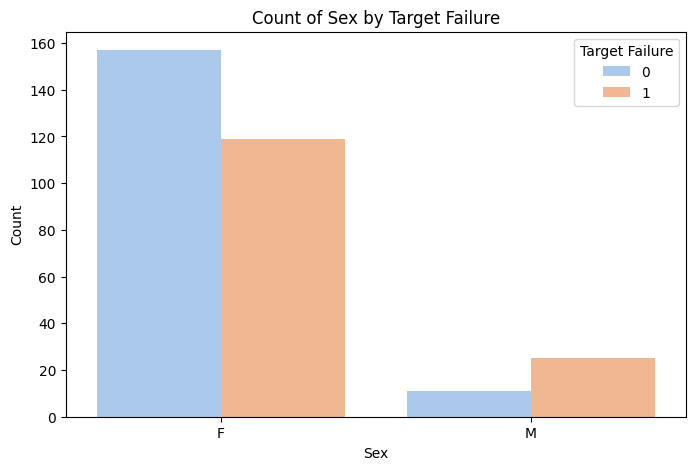

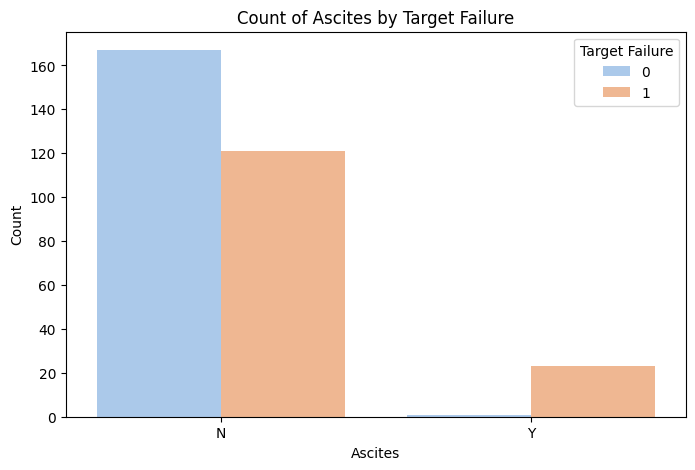

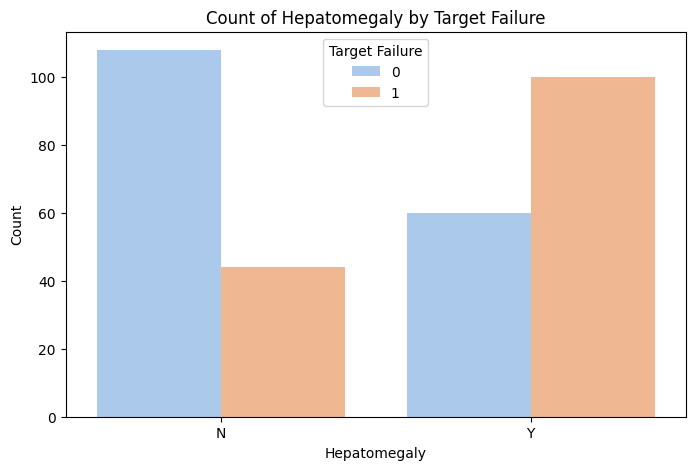

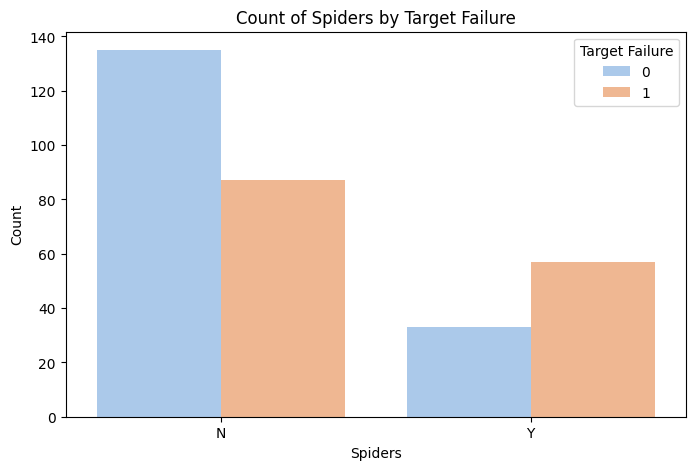

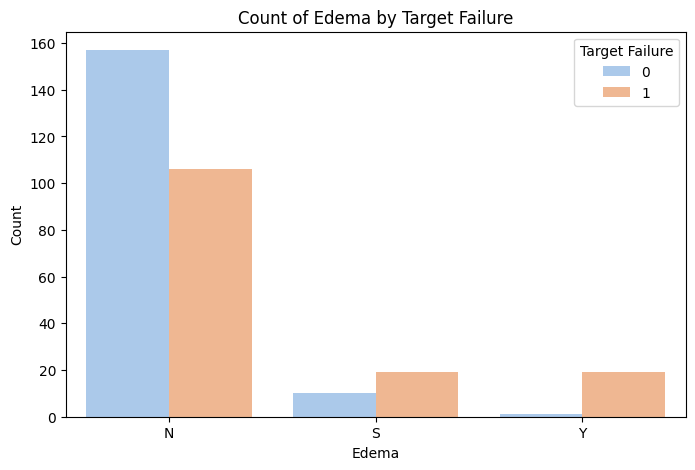

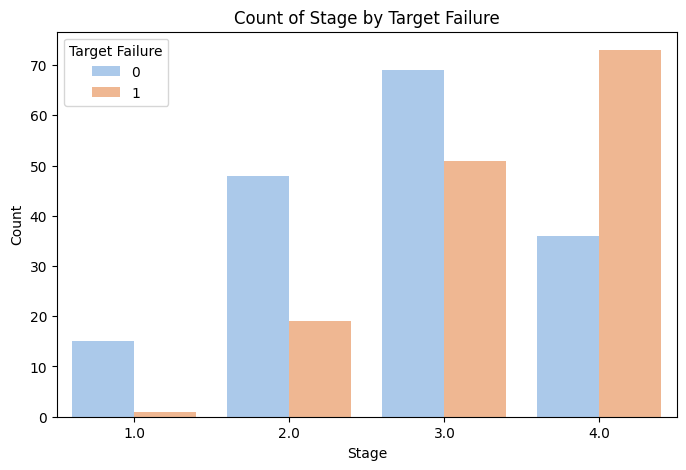

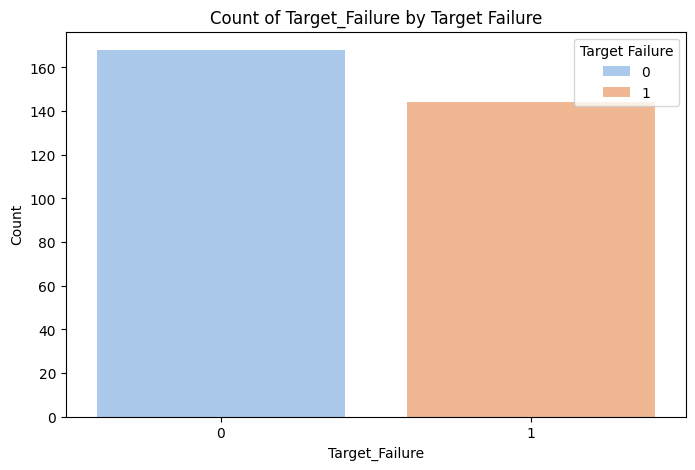

In [48]:
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue="Target_Failure", data=df, palette='pastel')
    plt.title(f"Count of {col} by Target Failure")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Target Failure")
    plt.show()

In [49]:
df.dtypes

,0
Drug,category
Age,float64
Sex,category
Ascites,category
Hepatomegaly,category
Spiders,category
Edema,category
Bilirubin,float64
Cholesterol,float64
Albumin,float64


## Summary: Data Analysis and Next Steps

* Noise Removal: The ID column was removed because it lacks predictive value. The N_Days column was completely removed from the pipeline to prevent data leakage, ensuring the model only trains on baseline measurements.

* Target Variable: The Status variable was transformed into a binary target: 'D' (Death) was mapped to 1, while 'C' (Censored) and 'CL' (Censored, liver transplant) were combined and mapped to 0.

* Categorical Type Casting: Binary features (Sex, Ascites, Hepatomegaly, Spiders) were mapped to numeric 1/0 values. Afterwards, all categorical features, including Drug, Edema, and Stage, were explicitly cast to the category data type to ensure algorithms process them as discrete groups rather than continuous numbers.

* Missing Value Handling: Rows with missing Drug values were dropped to maintain the integrity of a critical treatment variable . Remaining numerical missing values (e.g., Cholesterol, Copper) were processed using a KNNImputer (n\_neighbors=5).

## Patient Subgroup Identification (K-Prototypes Clustering)

* Pipeline Sequencing: Numerical features were isolated and processed with StandardScaler prior to clustering. This prevented features with naturally large magnitudes (like Age) from drowning out critical smaller-scale indicators (like Bilirubin) during Euclidean distance calculations.

* Optimal Clusters: The Elbow method indicated optimal_k=2, as the rate of cost reduction significantly diminished after this point .

* Cluster Interpretations: Cluster 1 represents patients with generally more severe clinical indicators (higher Bilirubin, Copper, Alk_Phos), suggesting a higher likelihood of mortality. Cluster 0 contains patients with milder clinical indicators.

## Key Predictors of Mortality (EDA)

* Numerical Predictors: Higher levels of Bilirubin, Copper, Alk_Phos, and SGOT, alongside lower Albumin and Platelet levels, are strongly associated with an increased likelihood of death .

* Categorical Predictors: The presence of Edema (especially 'Y'), the presence of Ascites ('Y'), and a higher disease Stage are strongly associated with mortality.